--- 1. LOADING DATA ---
--- 2. CLEANING & PREPROCESSING ---
--- 3. DATA INTEGRATION (BUILDING MASTER DATASET) ---
--- PROCESSING COMPLETE ---
Final Master Dataset Shape (Rows, Columns): (114068, 40)
--- 4. Feature Engineering ---
--- NEW VS REPEAT CUSTOMER ANALYSIS ---


C:\Users\Saptarshi Saha\AppData\Local\Temp\ipykernel_7188\34496666.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


--- SIMPLE HIGH-VALUE VS LOW-VALUE ANALYSIS ---
💰 The average customer spends: $173.45
--- GEOGRAPHIC DISTRIBUTION ---

--- TOP 10 STATES BY CUSTOMER COUNT ---
customer_state
SP    38642
RJ    11746
MG    10846
RS     5091
PR     4703
Name: customer_unique_id, dtype: int64
--- TOP-SELLING PRODUCT CATEGORIES (BY REVENUE) ---

--- TOP 10 CATEGORIES BY REVENUE ---
--- SIMPLE REVENUE CONTRIBUTION (TOP 10) ---
--- PRODUCT DEMAND DISTRIBUTION (TOP 10) ---

--- REVENUE BY MONTH ---
--- MONTHLY ORDER VOLUME TRENDS ---
--- PEAK SALES PERIODS (HOUR OF THE DAY) ---
--- TOP-PERFORMING SELLERS (BY REVENUE) ---
--- SIMPLE SELLER CONTRIBUTION (TOP 5 ONLY) ---
--- SELLER GEOGRAPHIC DISTRIBUTION (TOP 10 STATES) ---
--- REVIEW SCORE DISTRIBUTION ---

--- COUNT OF REVIEW SCORES ---
review_score
1.0    12873
2.0     3841
3.0     9536
4.0    21816
5.0    65153
Name: count, dtype: int64
--- RELATIONSHIP: DELIVERY TIME VS RATINGS ---
--- DISSATISFACTION PATTERNS (1-STAR REVIEWS) ---
--- STEP 6: DATA VISUALIZ

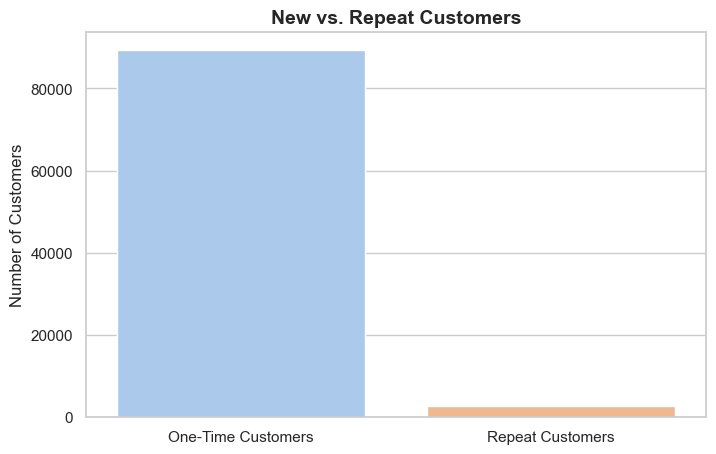

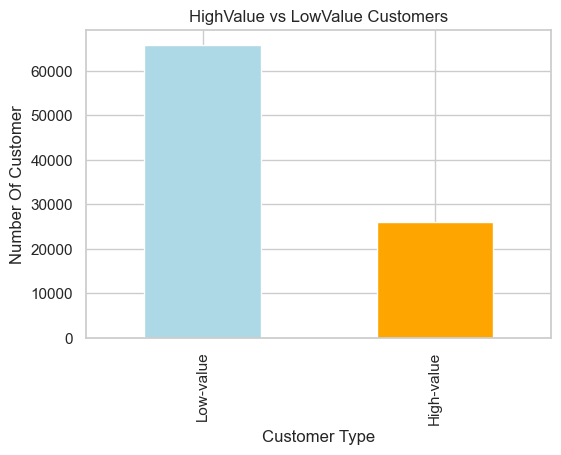

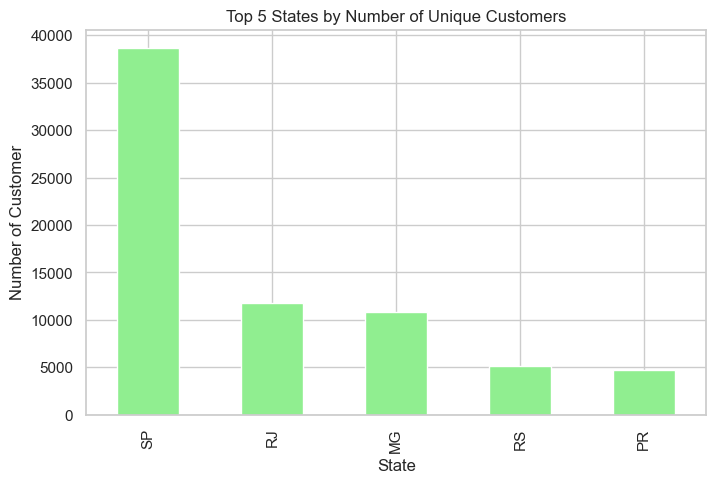

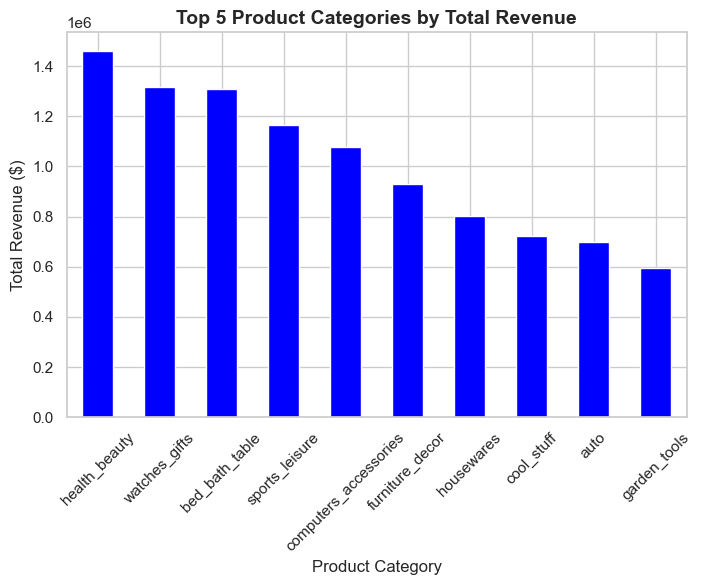

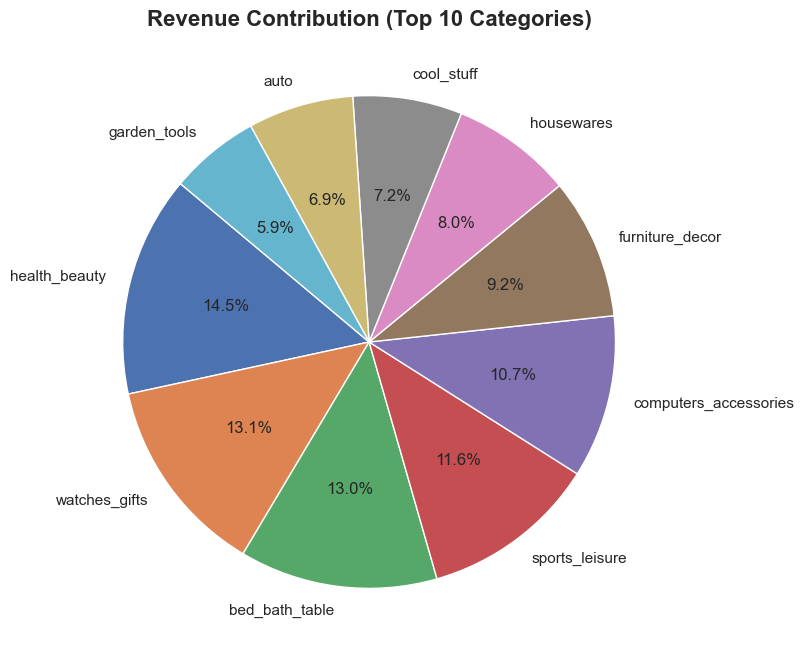

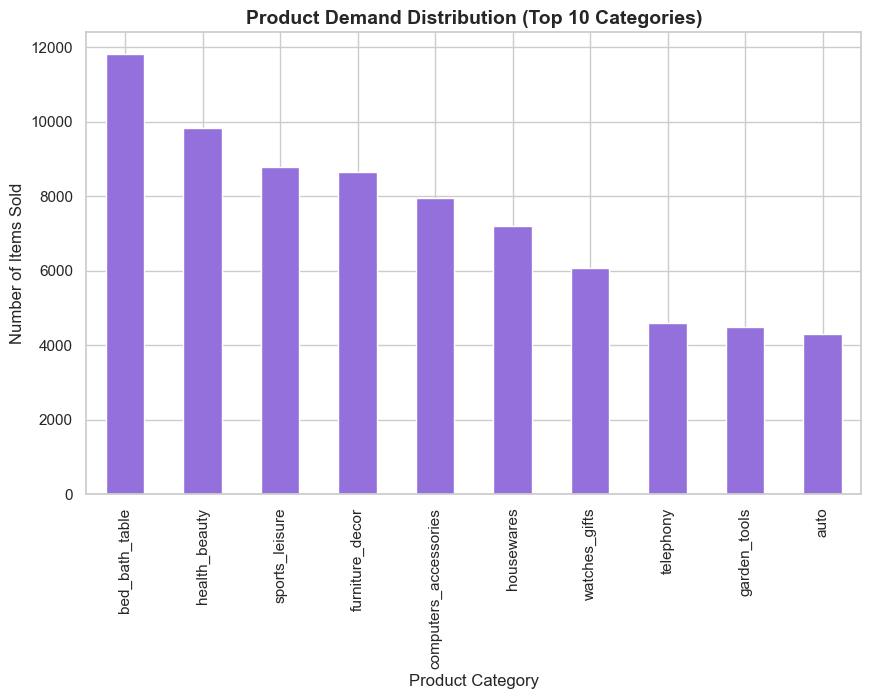

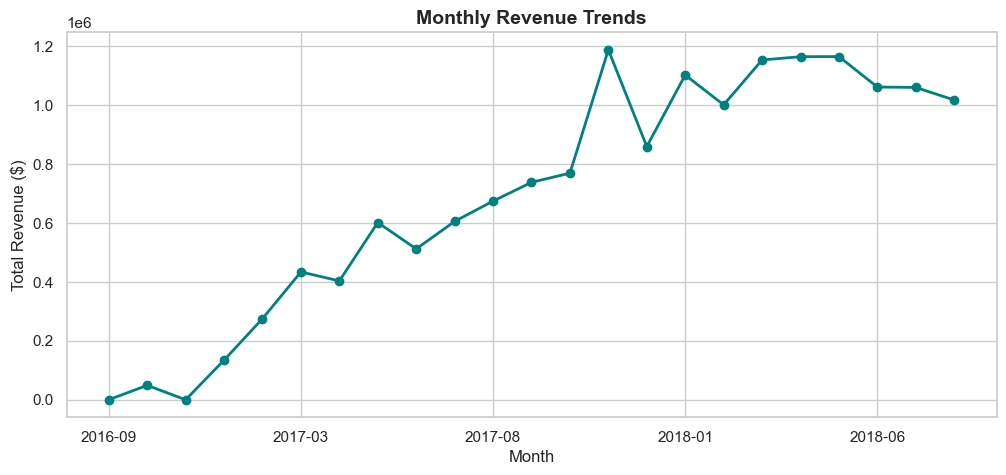

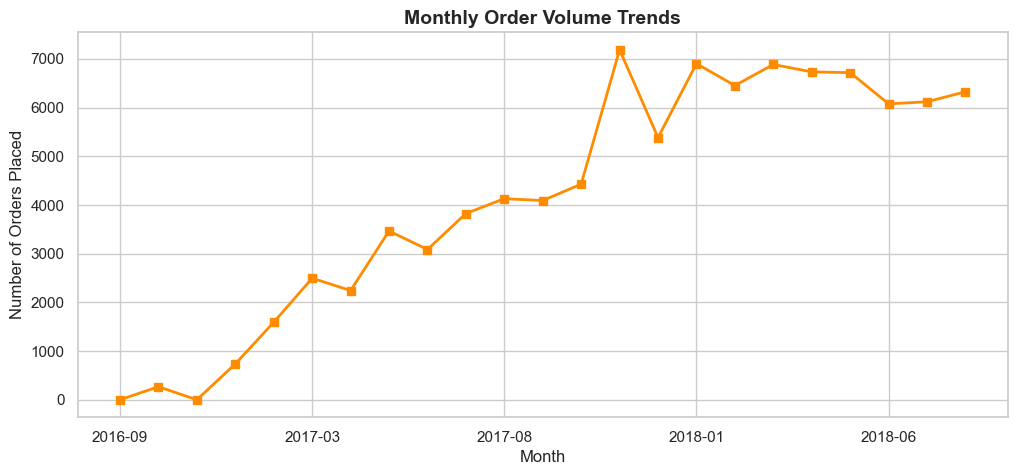

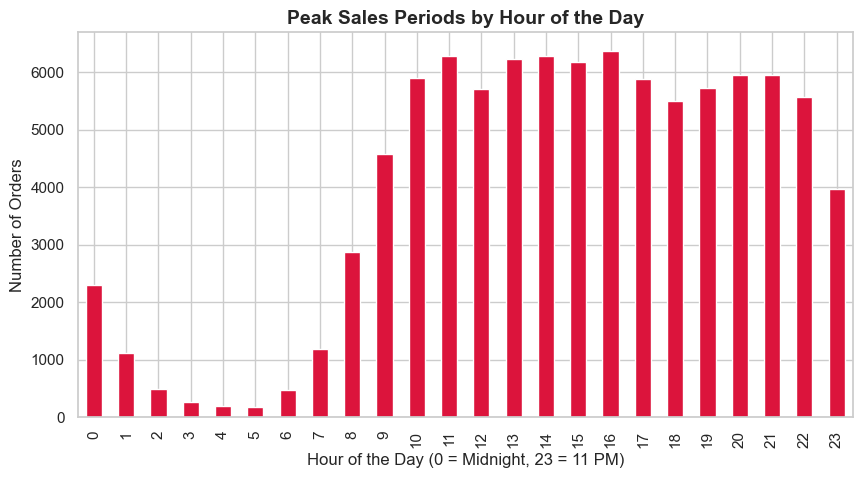

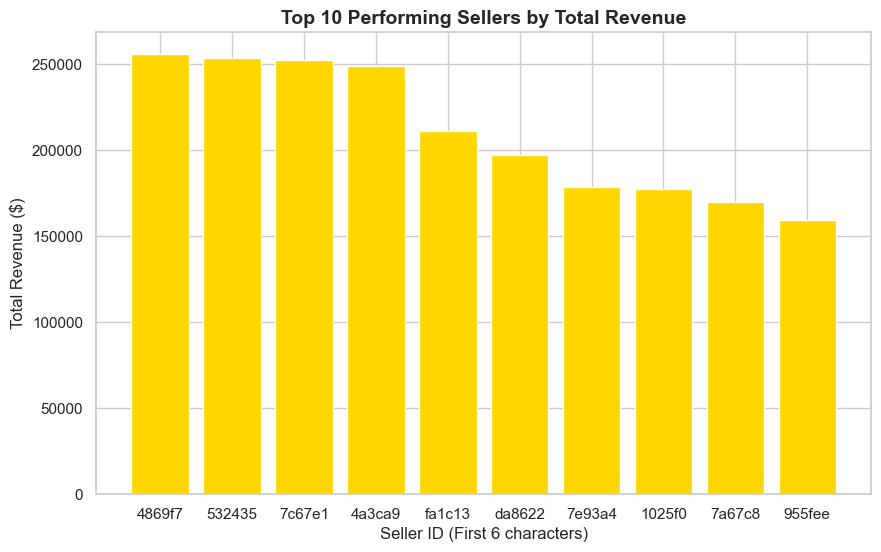

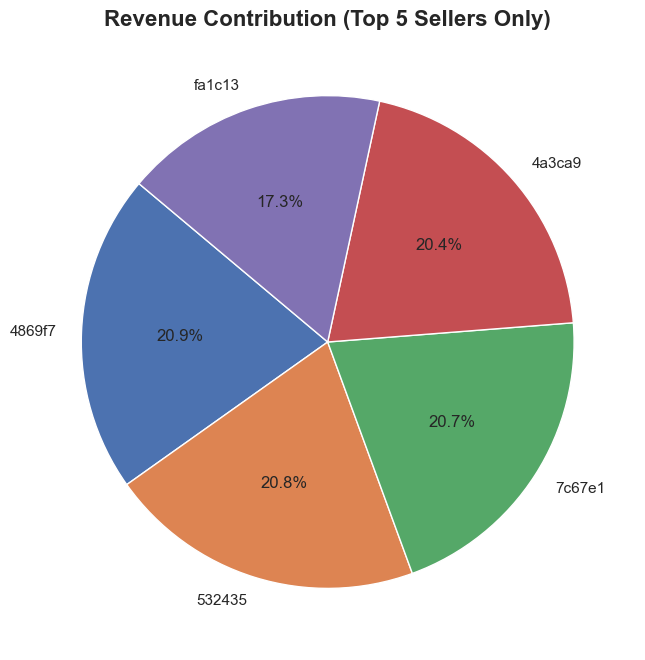

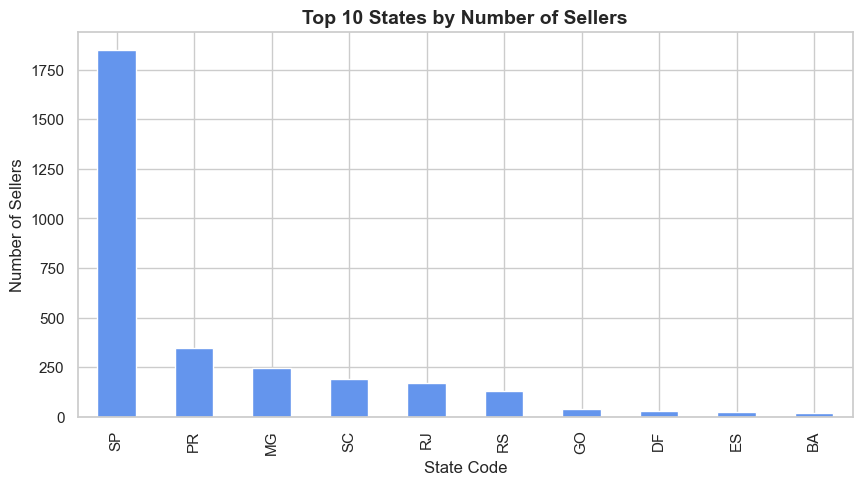

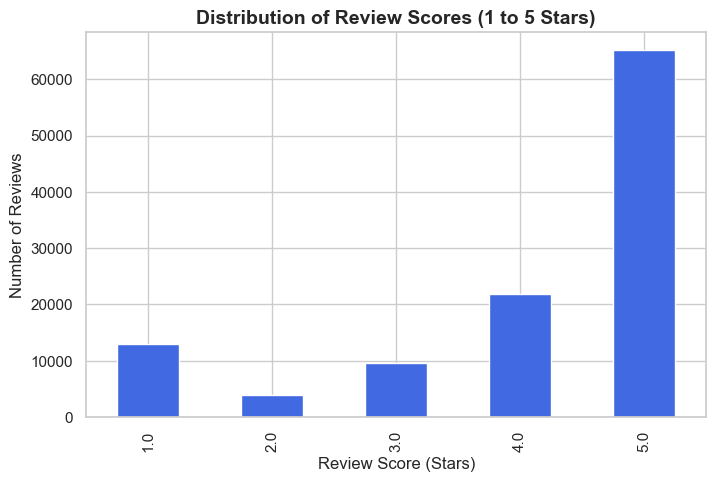

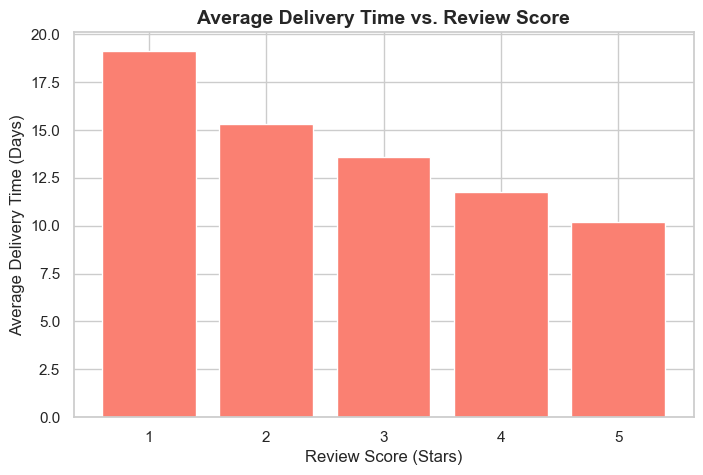

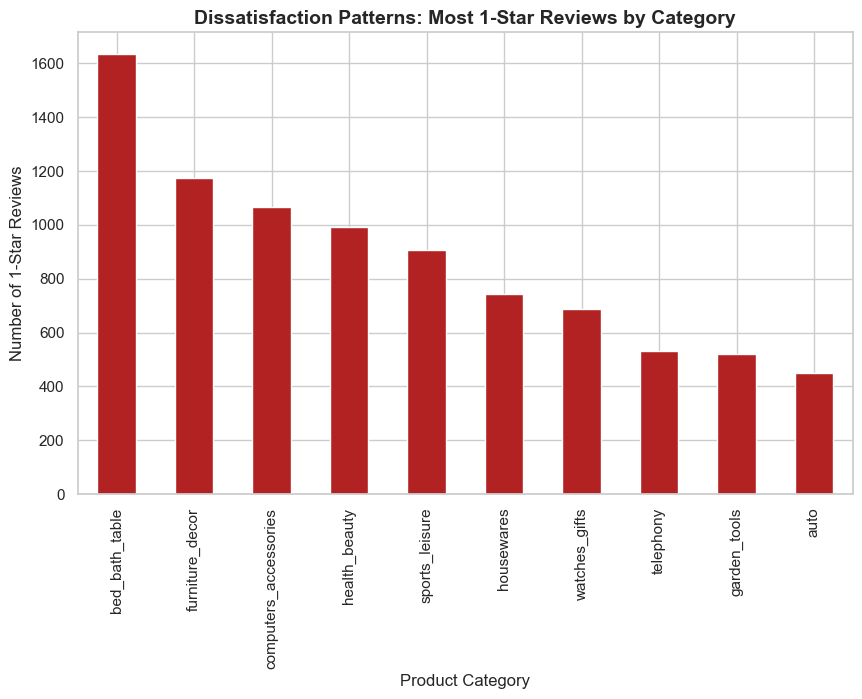

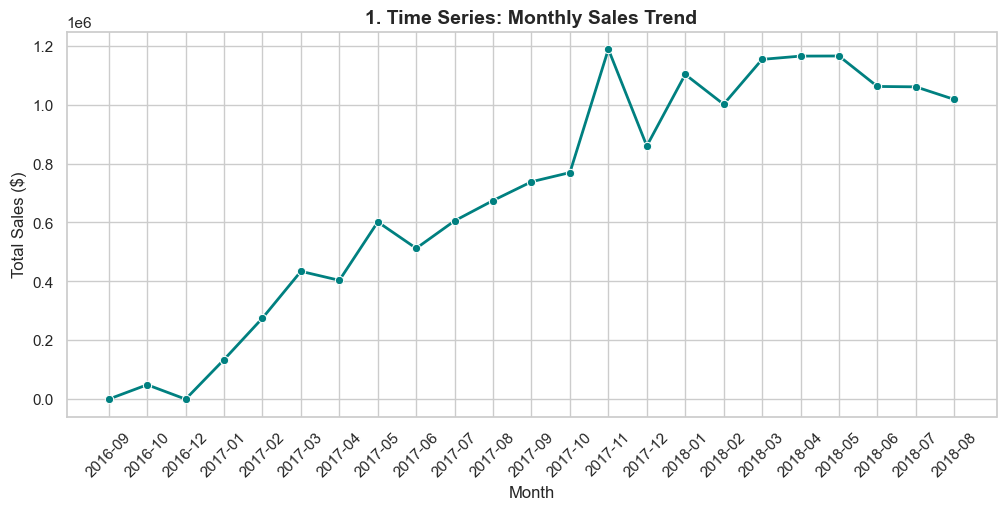

C:\Users\Saptarshi Saha\AppData\Local\Temp\ipykernel_7188\34496666.py:507: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


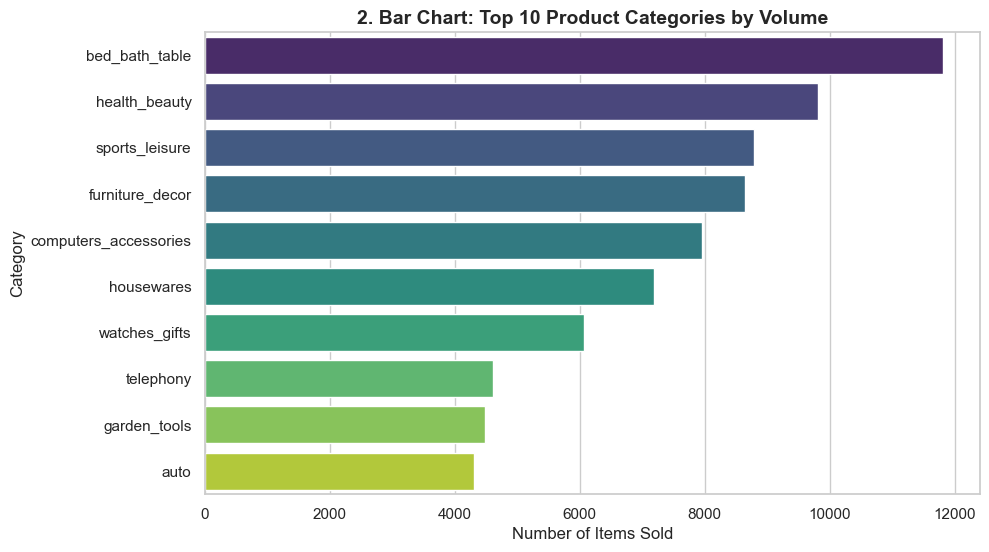

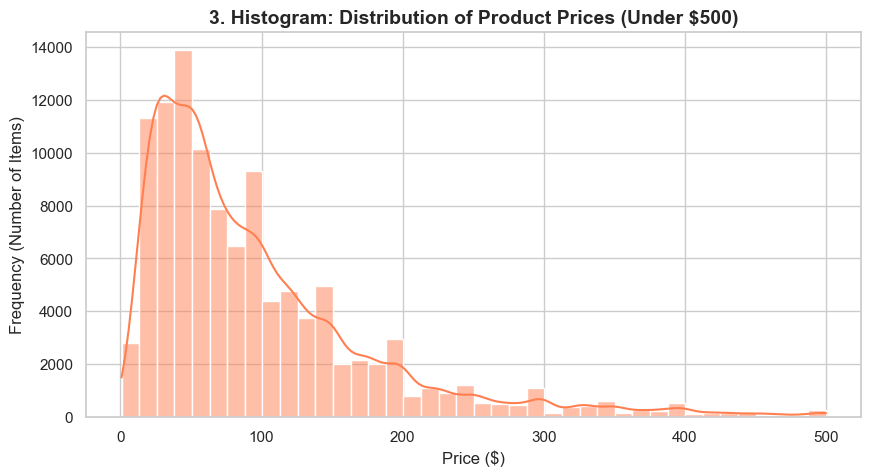

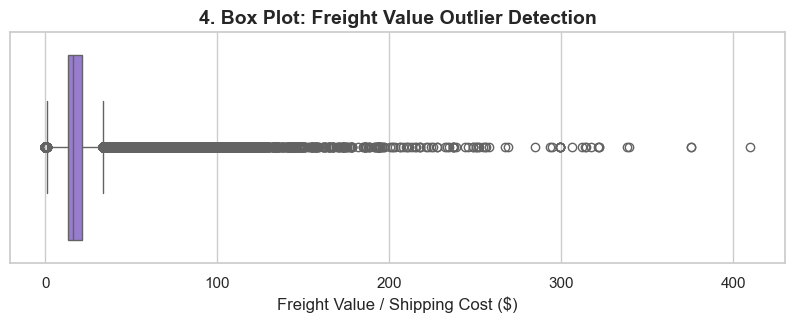

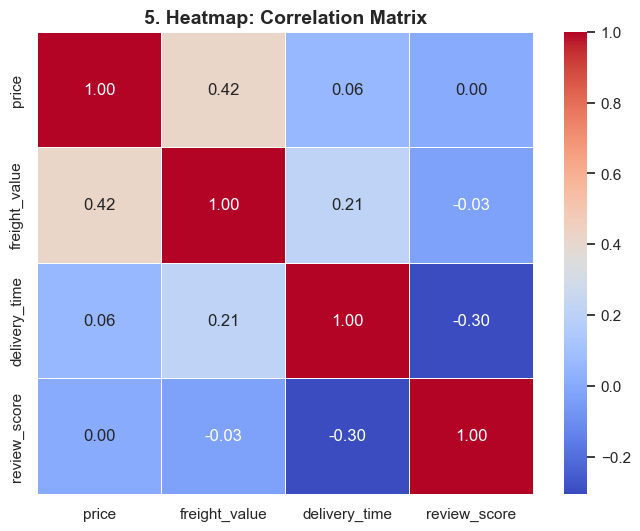

In [137]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Define your folders
RAW_FOLDER = 'C://Users//Saptarshi Saha//Ecommerce_Intelligence_System//Data'
# clean data to a new folder so you don't overwrite the raw data!
CLEAN_FOLDER = 'C://Users//Saptarshi Saha//Ecommerce_Intelligence_System//Cleaned_Data'

# Create the clean folder if it doesn't exist
os.makedirs(CLEAN_FOLDER, exist_ok=True)

print("--- 1. LOADING DATA ---")
orders = pd.read_csv(f"{RAW_FOLDER}//orders.csv")
category_translation = pd.read_csv(f"{RAW_FOLDER}//category_translation.csv")
customers = pd.read_csv(f"{RAW_FOLDER}//customers.csv")
location = pd.read_csv(f"{RAW_FOLDER}//location.csv")
order_item = pd.read_csv(f"{RAW_FOLDER}//order_item.csv")
payments = pd.read_csv(f"{RAW_FOLDER}//payments.csv")
reviews = pd.read_csv(f"{RAW_FOLDER}//reviews.csv")
products = pd.read_csv(f"{RAW_FOLDER}//products.csv")
sellers= pd.read_csv(f"{RAW_FOLDER}//sellers.csv")


print("--- 2. CLEANING & PREPROCESSING ---")

# --- Clean Orders ---
cols_to_drop = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
orders = orders.dropna(subset=cols_to_drop).copy()

cols_to_datachange = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in cols_to_datachange:
    orders[col] = pd.to_datetime(orders[col])

# --- Clean Order Items ---
order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'])

# --- Clean Products ---
prod_cols_to_drop = ['product_category_name', 'product_weight_g']
products = products.dropna(subset=prod_cols_to_drop).copy()

# --- Clean Reviews ---
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_score'] = pd.to_numeric(reviews['review_score'], errors='coerce')

# Check for and drop invalid review scores
valid_scores = reviews['review_score'].between(1, 5)
invalid_count = (~valid_scores).sum()
if invalid_count > 0:
    print(f"VALIDATION ALERT: Dropping {invalid_count} rows with impossible review scores.")
    # Here is where we actually drop the bad rows using the mask you created!
    reviews = reviews[valid_scores].copy() 

# --- Clean Location ---
location = location.drop_duplicates()


print("--- 3. DATA INTEGRATION (BUILDING MASTER DATASET) ---")

# Step 1: Merge Orders and Customers 
master_df = pd.merge(orders, customers, on='customer_id', how='inner')

# Step 2: Add Order Items 
master_df = pd.merge(master_df, order_item, on='order_id', how='inner')

# Step 3: Add Products details
master_df = pd.merge(master_df, products, on='product_id', how='inner')

# Step 4: Add Payments 
# (LEFT JOIN: Keep the order in our dataset even if payment info is missing)
master_df = pd.merge(master_df, payments, on='order_id', how='left')

# Step 5: Add Reviews 
# (LEFT JOIN: Keep the order in our dataset even if the customer didn't leave a review)
master_df = pd.merge(master_df, reviews, on='order_id', how='left')

# Step 6: Add Sellers details
master_df = pd.merge(master_df, sellers, on='seller_id', how='inner')


# Step 7: Add English Category Translations 
# (Left join: safe just in case a product category doesn't have an English translation yet)
master_df = pd.merge(master_df, category_translation, on='product_category_name', how='left')

print("--- PROCESSING COMPLETE ---")
print(f"Final Master Dataset Shape (Rows, Columns): {master_df.shape}")

# Inspect the final result
# print(master_df.head())
# master_df.info()

print("--- 4. Feature Engineering ---")

# 1. Total order value
master_df['total_item_cost'] = master_df['price'] + master_df['freight_value']
master_df['total_order_value'] = master_df.groupby('order_id')['total_item_cost'].transform('sum')

# 2. Delivery time
master_df['delivery_time'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.days

# 3. Number of items per order 
master_df['items_per_order'] = master_df.groupby('order_id')['order_item_id'].transform('max')

# 4. Customer purchase frequency 
master_df['customer_purchase_frequency'] = master_df.groupby('customer_id')['order_id'].transform('nunique')

# 5. Customer lifetime value
master_df['customer_lifetime_value'] = master_df.groupby('customer_id')['total_item_cost'].transform('sum')

# 6. Average order value per customer 
master_df['ave_order_value_customer'] = master_df['customer_lifetime_value'] / master_df['customer_purchase_frequency']

# Inspect the results!
#print(master_df[['customer_id', 'customer_purchase_frequency', 'customer_lifetime_value', 'ave_order_value_customer']].head())
#master_df
#New vs repeat customers 

print("--- NEW VS REPEAT CUSTOMER ANALYSIS ---")

# Step 1: Count how many unique orders each person made
customer_orders = master_df.groupby('customer_unique_id')['order_id'].nunique()

# Step 2: Categorize them! 
# If they have 1 order, they are "New". If more than 1, they are "Repeat".

new_customers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()

# Step 3: Set up the data for Seaborn
# We create a tiny DataFrame just for our chart.
chart_data = pd.DataFrame({
    'Customer Type': ['One-Time Customers', 'Repeat Customers'],
    'Count': [new_customers, repeat_customers]
})

# Step 4: VISUALIZATION WITH SEABORN
# Set the overall look 
sns.set_theme(style="whitegrid")

# Create the figure size
plt.figure(figsize=(8, 5))

# Create the bar chart! 
# Notice how we just point it to our tiny DataFrame and tell it the column names.
ax = sns.barplot(
    data=chart_data, 
    x='Customer Type', 
    y='Count', 
    palette='pastel'
)

# Add titles and labels
plt.title('New vs. Repeat Customers', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12)
plt.xlabel('') 

print("--- SIMPLE HIGH-VALUE VS LOW-VALUE ANALYSIS ---")

# Step 1: Calculate how much each customer spent in total
# We use .sum() and then .reset_index() to turn it back into a normal DataFrame
customer_spent = master_df.groupby('customer_unique_id')['total_item_cost'].sum().reset_index()

# Let's rename the columns so they are super easy to read
customer_spent.columns = ['customer_unique_id', 'total_spent']


# Step 2: Calculate the Average Spend (This is our simple cut-off point)
average_spend = customer_spent['total_spent'].mean()
print(f"💰 The average customer spends: ${average_spend:.2f}")

# Step 3: Categorize customers 
# First, create the column and make EVERYONE "Low-Value"
customer_spent['segment'] = 'Low-value'

# Second, use .loc (location) to find people who spent MORE than average, and change their label
customer_spent.loc[customer_spent['total_spent']>= average_spend, 'segment'] = 'High-value'

# Step 4: Count how many people are in each group
segment_counts= customer_spent['segment'].value_counts()
segment_percent = customer_spent['segment'].value_counts(normalize=True)
segment_percent = segment_percent*100

#print("\n--- SEGMENT COUNTS ---")
#print(segment_counts, segment_percent)

# Step 5: Make a Bar Chart 

plt.figure(figsize=(6,4))
segment_counts.plot(kind='bar', color=['lightblue', 'orange'])

plt.title('HighValue vs LowValue Customers')
plt.ylabel('Number Of Customer')
plt.xlabel('Customer Type')

print("--- GEOGRAPHIC DISTRIBUTION ---")
master_df.head()
# Step 1: Group by State and count UNIQUE customers

state_country = master_df.groupby('customer_state')['customer_unique_id'].nunique()
# Step 2: Sort them from highest to lowest, and grab the Top 5
top_10_state = state_country.sort_values(ascending=False).head(5)

print("\n--- TOP 10 STATES BY CUSTOMER COUNT ---")
print(top_10_state)

# Step 3: Make Bar Chart

plt.figure(figsize=(8,5))

top_10_state.plot(kind='bar', color='lightgreen')
plt.title('Top 5 States by Number of Unique Customers')
plt.ylabel('Number of Customer')
plt.xlabel('State')

#Top-selling product categories 
print("--- TOP-SELLING PRODUCT CATEGORIES (BY REVENUE) ---")

# Step 1: Group by the category and sum up the total money made
category_revenue = master_df.groupby('product_category_name_english')['total_item_cost'].sum()

# Step 2: Sort from highest to lowest, and grab the Top 10
top_10_category = category_revenue.sort_values(ascending=False).head(10)

print("\n--- TOP 10 CATEGORIES BY REVENUE ---")
#print(top_10_category)

# Step 3: Make a simple Bar Chart
plt.figure(figsize=(8,5))
top_10_category.plot(kind='bar', color = 'blue')

plt.title('Top 5 Product Categories by Total Revenue', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Product Category')

# xticks  rotate the long category names by 45 degrees so they are easy to read!
plt.xticks(rotation=45)

print("--- SIMPLE REVENUE CONTRIBUTION (TOP 10) ---")

# Step 1: Calculate the total revenue and grab the Top 10
category_revenue = master_df.groupby('product_category_name_english')['total_item_cost'].sum().reset_index()

# Sort highest to lowest and keep only the Top 5 rows
top_10_categories = category_revenue.sort_values(by='total_item_cost', ascending=False).head(10)


# Step 2: Create the Pie Chart
plt.figure(figsize=(8, 8))

# We just feed Matplotlib our Top 10 table!
plt.pie(
    top_10_categories['total_item_cost'], 
    labels=top_10_categories['product_category_name_english'], 
    autopct='%1.1f%%',  # This automatically calculates the percentages for the chart!
    startangle=140
)

plt.title('Revenue Contribution (Top 10 Categories)', fontsize=16, fontweight='bold')

print("--- PRODUCT DEMAND DISTRIBUTION (TOP 10) ---")

# Step 1: Count how many times each category was bought
demand_distribution = master_df['product_category_name_english'].value_counts().head(10)

#print("\n--- TOP 10 MOST DEMANDED CATEGORIES ---")
#print(demand_distribution)


# Step 2: Make a Bar Chart
plt.figure(figsize=(10, 6))

demand_distribution.plot(kind='bar', color='mediumpurple')

plt.title('Product Demand Distribution (Top 10 Categories)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Items Sold', fontsize=12)
plt.xlabel('Product Category', fontsize=12)

# Rotate the labels so they are easy to read
#plt.xticks(rotation=45, ha='right')

#print("--- MONTHLY REVENUE TRENDS ---")

# Step 1: Extract just the Year and Month
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.strftime('%Y-%m')

# Step 2: Group by this new month column and sum up the revenue
monthly_revenue = master_df.groupby('order_month')['total_item_cost'].sum()

print("\n--- REVENUE BY MONTH ---")
#print(monthly_revenue)

# Step 3: Make a simple Line Chart
plt.figure(figsize=(12, 5))

monthly_revenue.plot(kind='line', color='teal', marker='o' ,linewidth=2)

plt.title('Monthly Revenue Trends', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)

print("--- MONTHLY ORDER VOLUME TRENDS ---")

# Step 1: Create the Month column
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.strftime('%Y-%m')

# Step 2: Group by month and count the UNIQUE orders
monthly_volumn = master_df.groupby('order_month')['order_id'].nunique()

#print("\n--- ORDER VOLUME BY MONTH ---")
#print(monthly_volumn)

#step 3 create line chart

plt.figure(figsize=(12,5))

monthly_volumn.plot(kind='line', color= 'darkorange', marker='s',linewidth=2)

plt.title('Monthly Order Volume Trends', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders Placed', fontsize=12)
plt.xlabel('Month', fontsize=12)

print("--- PEAK SALES PERIODS (HOUR OF THE DAY) ---")

# Step 1: Extract the Hour from the timestamp
master_df['order_hour'] = master_df['order_purchase_timestamp'].dt.hour

# Step 2: Group by the hour and count the UNIQUE orders
# use .nunique() so we don't accidentally count 1 order multiple times!
peak_hours = master_df.groupby('order_hour')['order_id'].nunique()

# Step 3: Make a simple Bar Chart
plt.figure(figsize=(10, 5))

peak_hours.plot(kind='bar', color='crimson')

plt.title('Peak Sales Periods by Hour of the Day', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=12)
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)

print("--- TOP-PERFORMING SELLERS (BY REVENUE) ---")

#step 1 seller revenue 

seller_revenue = master_df.groupby('seller_id')['total_item_cost'].sum().reset_index()

# Step 2: Sort from highest to lowest and grab the Top 10
top_10_sellers = seller_revenue.sort_values(by='total_item_cost', ascending=False).head(10)

#print("\n--- TOP 10 SELLERS BY REVENUE ---")
#print(top_10_sellers)


# Step 3: Make a simple Bar Chart
plt.figure(figsize=(10, 6))

#.str[:6]! This safely shortens the huge IDs just for the chart labels
short_seller_ids = top_10_sellers['seller_id'].astype(str).str[:6]

# Draw the chart using a nice gold color
plt.bar(short_seller_ids, top_10_sellers['total_item_cost'], color='gold')

plt.title('Top 10 Performing Sellers by Total Revenue', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xlabel('Seller ID (First 6 characters)', fontsize=12)

print("--- SIMPLE SELLER CONTRIBUTION (TOP 5 ONLY) ---")

# Step 1: Calculate total revenue for each seller, sort them, and keep ONLY the Top 5
seller_revenue = master_df.groupby('seller_id')['total_item_cost'].sum().reset_index()
top_5_sellers = seller_revenue.sort_values(by='total_item_cost', ascending=False).head(5).copy()

# Shorten the massive IDs to just 6 letters so the chart doesn't look messy
top_5_sellers['seller_id'] = top_5_sellers['seller_id'].astype(str).str[:6]


# Step 2: Make the Pie Chart!
plt.figure(figsize=(8, 8))

# We just hand our Top 5 table straight to Matplotlib
plt.pie(
    top_5_sellers['total_item_cost'], 
    labels=top_5_sellers['seller_id'], 
    autopct='%1.1f%%', # This does the percentage math automatically!
    startangle=140
)

plt.title('Revenue Contribution (Top 5 Sellers Only)', fontsize=16, fontweight='bold')

print("--- SELLER GEOGRAPHIC DISTRIBUTION (TOP 10 STATES) ---")

# Step 1: Count how many sellers are in each state
seller_distribution = sellers['seller_state'].value_counts().head(10)

#print("\n--- TOP 10 STATES BY SELLER COUNT ---")
#print(seller_distribution)


# Step 2: Make a simple Bar Chart
plt.figure(figsize=(10, 5))

seller_distribution.plot(kind='bar', color='cornflowerblue')

plt.title('Top 10 States by Number of Sellers', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sellers', fontsize=12)
plt.xlabel('State Code', fontsize=12)

print("--- REVIEW SCORE DISTRIBUTION ---")

# Step 1: Count how many of each review score we have

score_distribution = master_df['review_score'].value_counts().sort_index()

print("\n--- COUNT OF REVIEW SCORES ---")
print(score_distribution)


# Step 2: Make a simple Bar Chart
plt.figure(figsize=(8, 5))

# We use a nice royal blue color for the bars
score_distribution.plot(kind='bar', color='royalblue')

plt.title('Distribution of Review Scores (1 to 5 Stars)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Reviews', fontsize=12)
plt.xlabel('Review Score (Stars)', fontsize=12)

print("--- RELATIONSHIP: DELIVERY TIME VS RATINGS ---")

# Step 1: Group by the review score and find the AVERAGE delivery time
# We use .mean() to find the average number of days it took
delivery_by_score = master_df.groupby('review_score')['delivery_time'].mean().reset_index()

#print("\n--- AVERAGE DELIVERY TIME BY REVIEW SCORE ---")
#print(delivery_by_score)


# Step 2: Make a simple Bar Chart
plt.figure(figsize=(8, 5))

# We use a nice coral/salmon color for this one
plt.bar(delivery_by_score['review_score'], delivery_by_score['delivery_time'], color='salmon')

plt.title('Average Delivery Time vs. Review Score', fontsize=14, fontweight='bold')
plt.ylabel('Average Delivery Time (Days)', fontsize=12)
plt.xlabel('Review Score (Stars)', fontsize=12)


print("--- DISSATISFACTION PATTERNS (1-STAR REVIEWS) ---")

# Step 1: Filter the dataset! 
angry_customers = master_df[master_df['review_score'] == 1]

# Step 2: Count which categories have the most 1-star reviews
bad_categories = angry_customers['product_category_name_english'].value_counts().head(10)

#print("\n--- TOP 10 CATEGORIES WITH 1-STAR REVIEWS ---")
#print(bad_categories)


# Step 3: Make a Bar Chart
plt.figure(figsize=(10, 6))

bad_categories.plot(kind='bar', color='firebrick')

plt.title('Dissatisfaction Patterns: Most 1-Star Reviews by Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of 1-Star Reviews', fontsize=12)
plt.xlabel('Product Category', fontsize=12)

sns.set_theme(style="whitegrid")

print("--- STEP 6: DATA VISUALIZATION GENERATOR ---")

# ---------------------------------------------------------
# 1. TIME SERIES PLOT (Sales Trends)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
# Ensure we have our month column
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_sales = master_df.groupby('order_month')['total_item_cost'].sum()

# We use a line plot for time series
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, color='teal', marker='o', linewidth=2)
plt.title('1. Time Series: Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.show()


# ---------------------------------------------------------
# 2. BAR CHART (Category Performance)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
top_categories = master_df['product_category_name_english'].value_counts().head(10)

# Seaborn makes bar charts instantly
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('2. Bar Chart: Top 10 Product Categories by Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Items Sold')
plt.ylabel('Category')
plt.show()


# ---------------------------------------------------------
# 3. HISTOGRAM (Distribution Analysis)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
# We filter price to < $500 just so the chart isn't ruined by a single $10,000 item
normal_prices = master_df[master_df['price'] < 500]

# Histograms show the "shape" of our data 
sns.histplot(data=normal_prices, x='price', bins=40, color='coral', kde=True)
plt.title('3. Histogram: Distribution of Product Prices (Under $500)', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Frequency (Number of Items)')
plt.show()


# ---------------------------------------------------------
# 4. BOX PLOT (Outlier Detection)
# ---------------------------------------------------------
plt.figure(figsize=(10, 3))

# Box plots are the absolute best way to spot crazy outliers
sns.boxplot(data=master_df, x='freight_value', color='mediumpurple')
plt.title('4. Box Plot: Freight Value Outlier Detection', fontsize=14, fontweight='bold')
plt.xlabel('Freight Value / Shipping Cost ($)')
plt.show()


# ---------------------------------------------------------
# 5. HEATMAP (Correlation Analysis)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# First, we pick ONLY the number columns we want to compare
cols_to_compare = ['price', 'freight_value', 'delivery_time', 'review_score']
correlation_matrix = master_df[cols_to_compare].corr()

# Annot=True prints the exact numbers inside the boxes!
# cmap='coolwarm' makes strong positive correlations red, and negative ones blue
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('5. Heatmap: Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()



--- 1. LOADING DATA ---
--- 2. CLEANING & PREPROCESSING ---
--- 3. DATA INTEGRATION (BUILDING MASTER DATASET) ---
--- PROCESSING COMPLETE ---
Final Master Dataset Shape (Rows, Columns): (114068, 40)
--- 4. Feature Engineering ---
--- NEW VS REPEAT CUSTOMER ANALYSIS ---


C:\Users\Saptarshi Saha\AppData\Local\Temp\ipykernel_7188\690033366.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=chart_data, x='Customer Type', y='Count', palette='pastel')


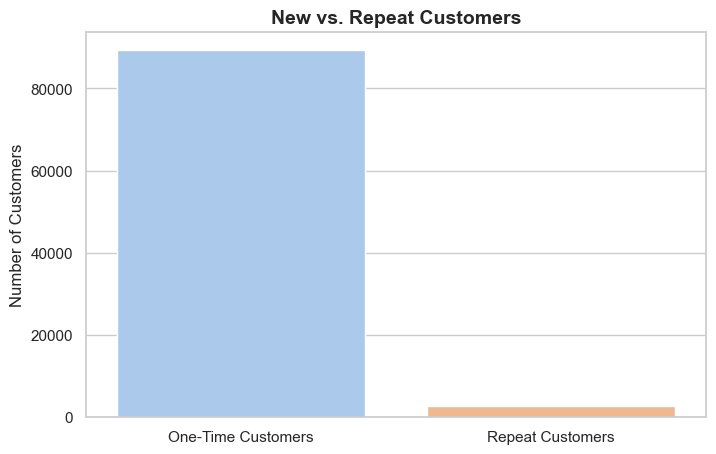

--- SIMPLE HIGH-VALUE VS LOW-VALUE ANALYSIS ---


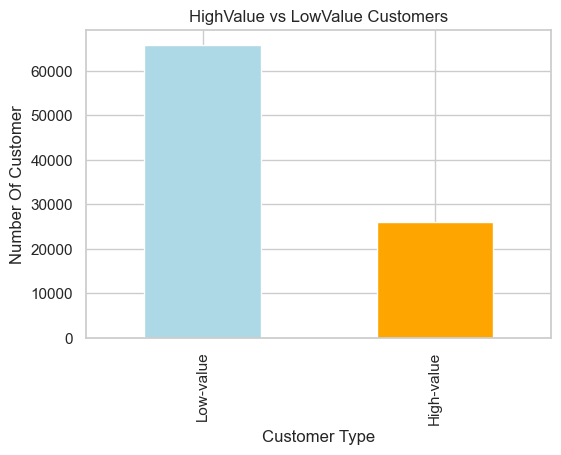

--- GEOGRAPHIC DISTRIBUTION ---

--- TOP 5 STATES BY CUSTOMER COUNT ---
customer_state
SP    38642
RJ    11746
MG    10846
RS     5091
PR     4703
Name: customer_unique_id, dtype: int64


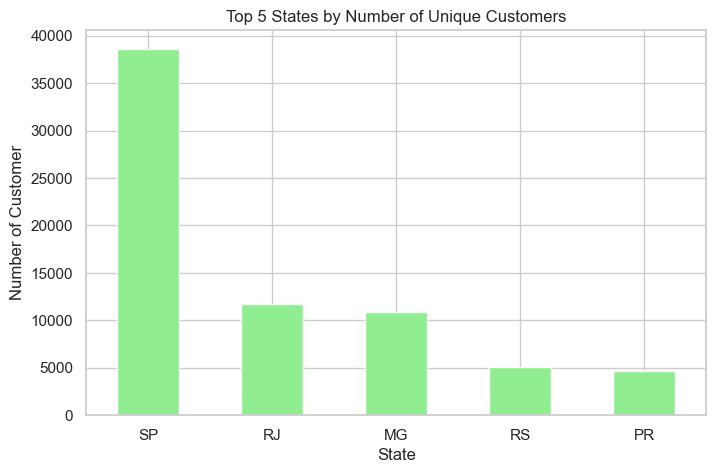

--- TOP-SELLING PRODUCT CATEGORIES (BY REVENUE) ---


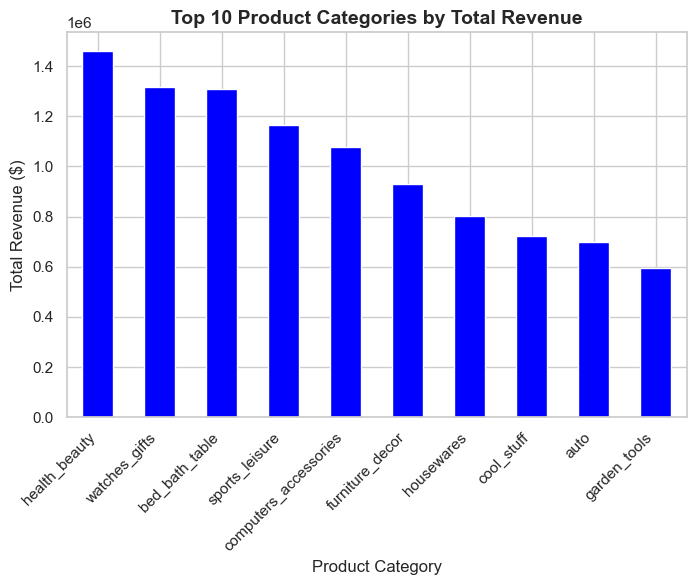

--- SIMPLE REVENUE CONTRIBUTION (TOP 10) ---


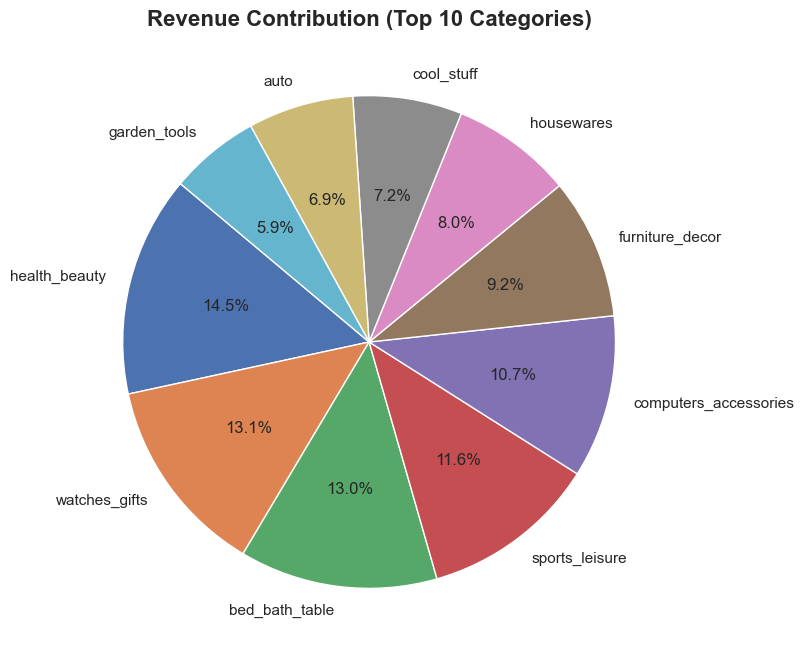

--- PRODUCT DEMAND DISTRIBUTION (TOP 10) ---


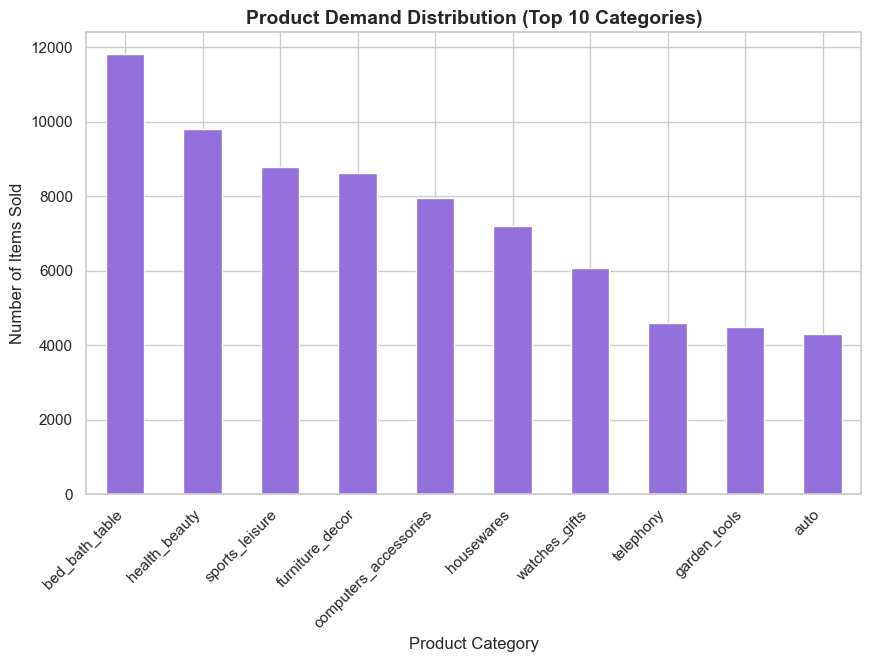

--- MONTHLY REVENUE TRENDS ---


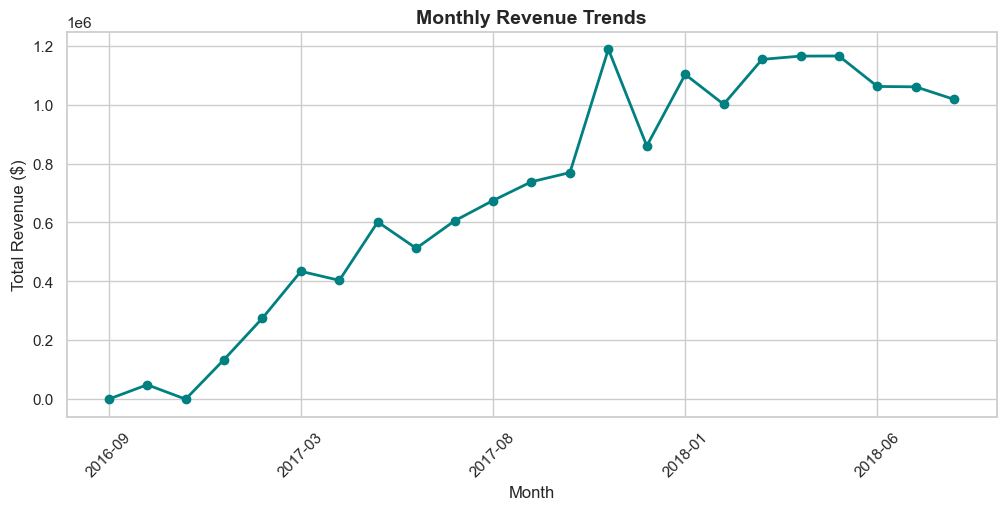

--- MONTHLY ORDER VOLUME TRENDS ---


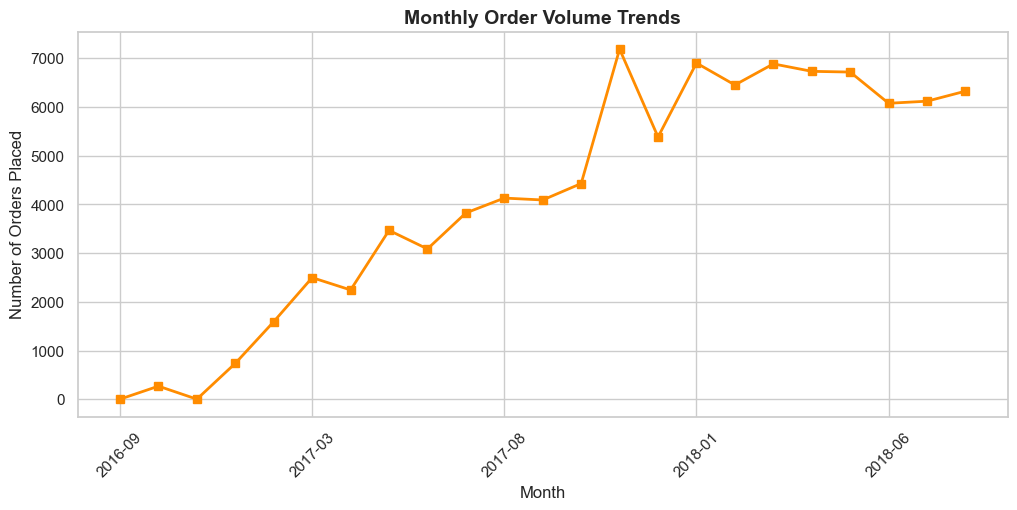

--- PEAK SALES PERIODS (HOUR OF THE DAY) ---


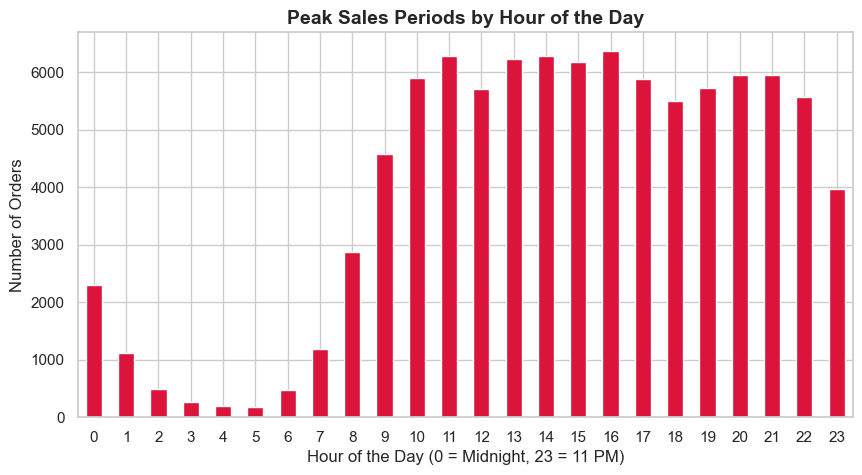

--- TOP-PERFORMING SELLERS (BY REVENUE) ---


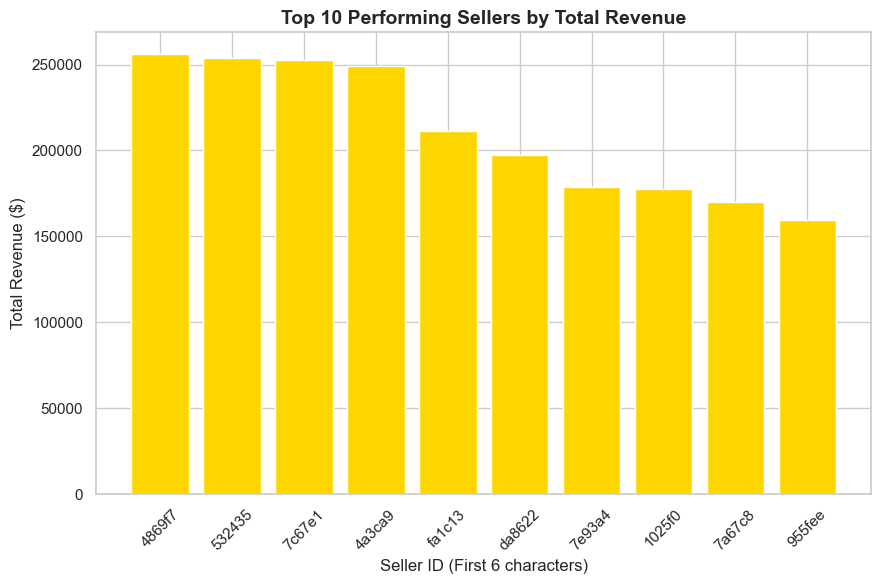

--- SIMPLE SELLER CONTRIBUTION (TOP 5 ONLY) ---


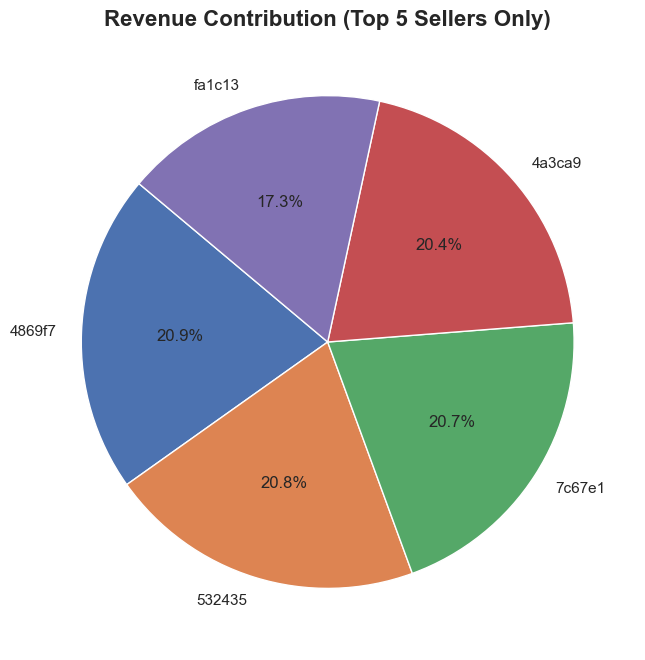

--- SELLER GEOGRAPHIC DISTRIBUTION (TOP 10 STATES) ---


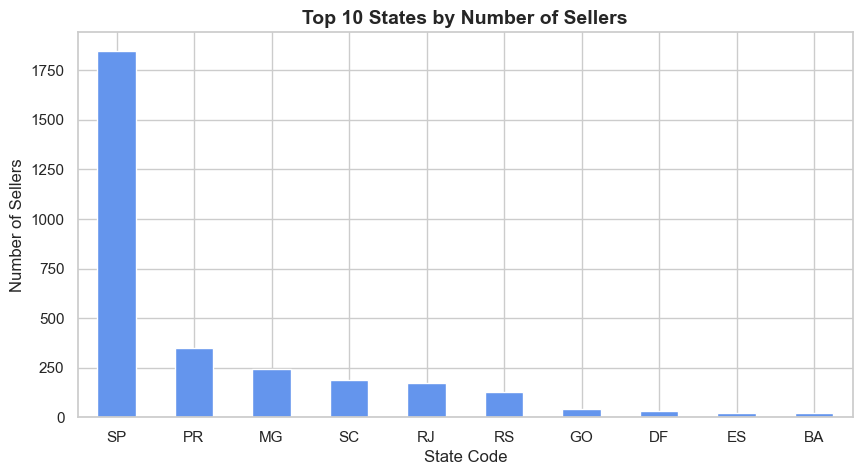

--- REVIEW SCORE DISTRIBUTION ---

--- COUNT OF REVIEW SCORES ---
review_score
1.0    12873
2.0     3841
3.0     9536
4.0    21816
5.0    65153
Name: count, dtype: int64


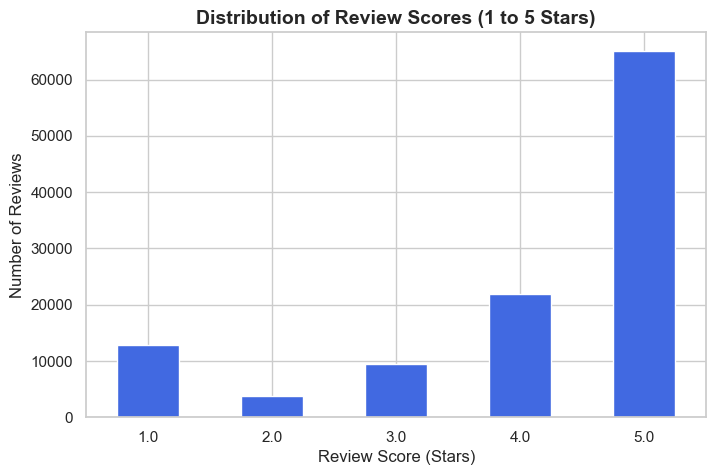

--- RELATIONSHIP: DELIVERY TIME VS RATINGS ---


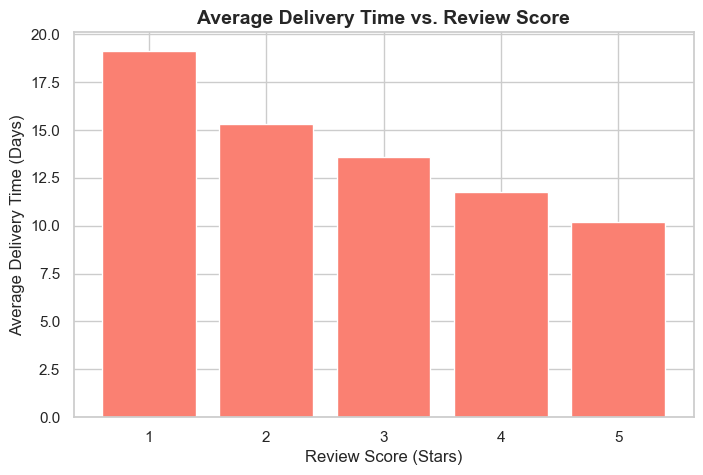

--- DISSATISFACTION PATTERNS (1-STAR REVIEWS) ---


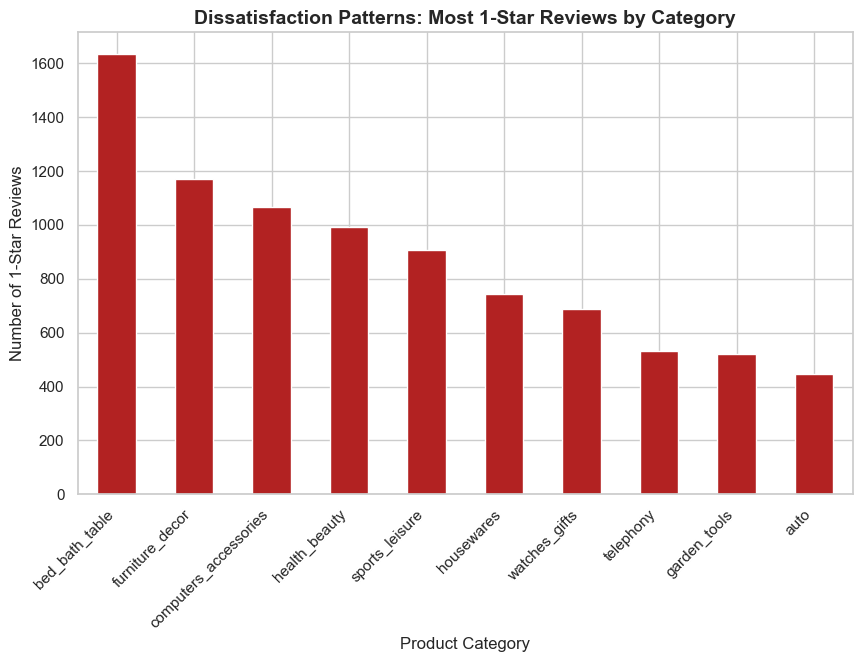

--- STEP 6: DATA VISUALIZATION GENERATOR ---


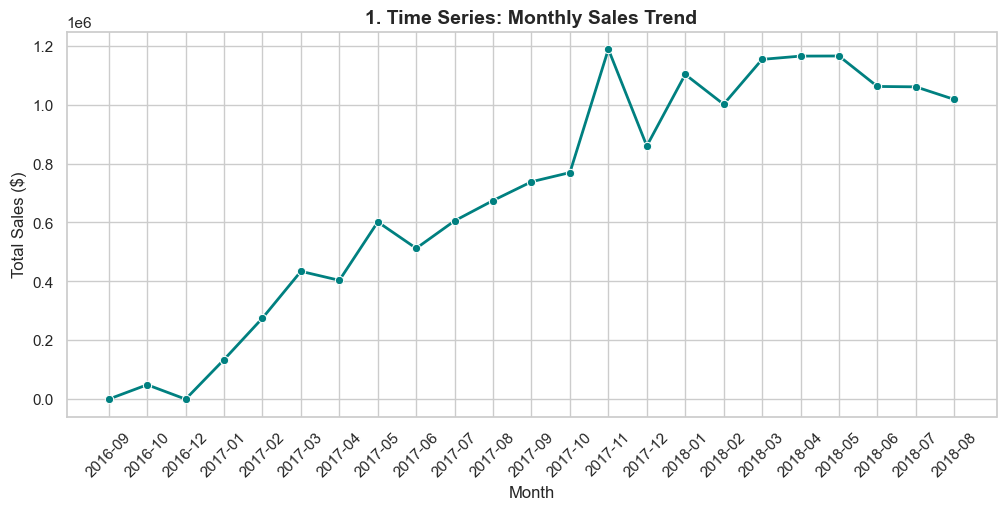

C:\Users\Saptarshi Saha\AppData\Local\Temp\ipykernel_7188\690033366.py:381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


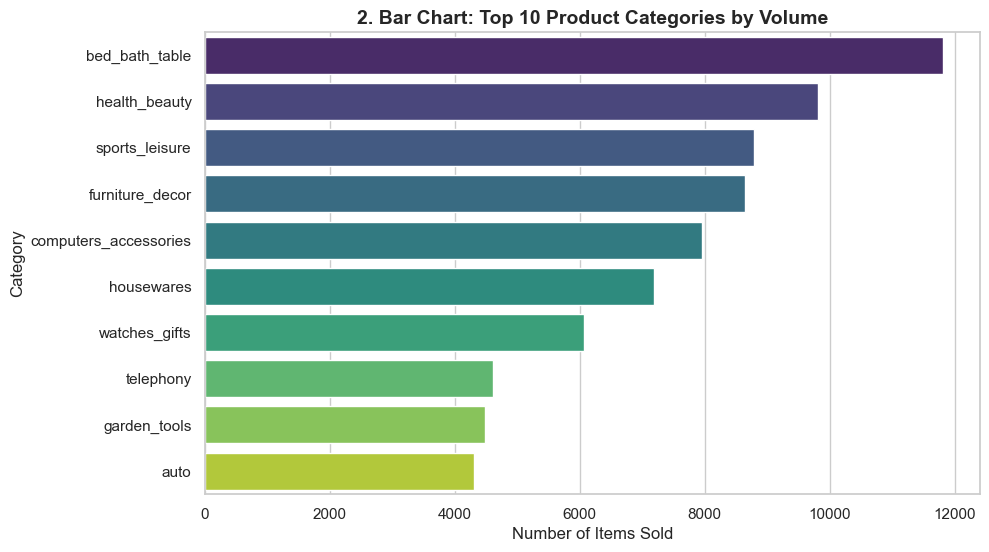

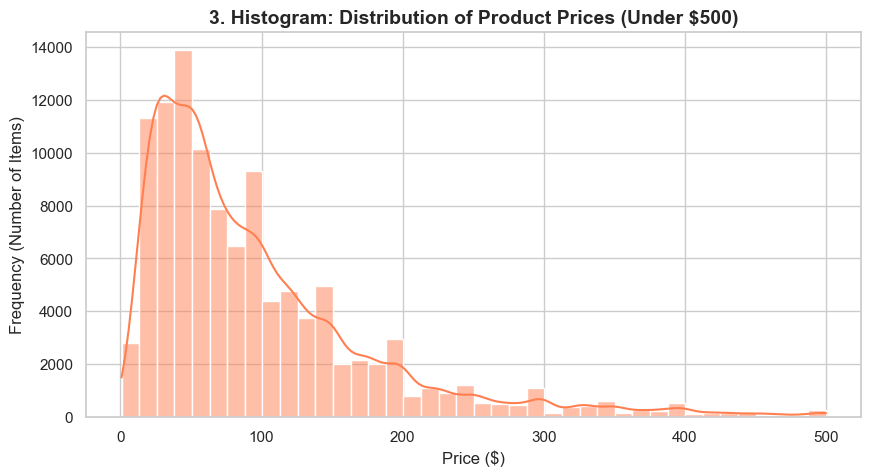

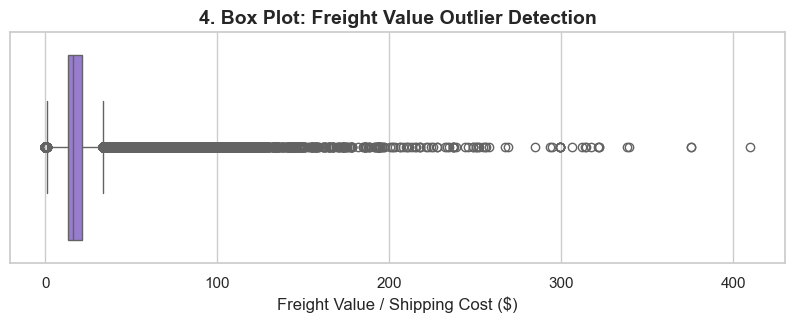

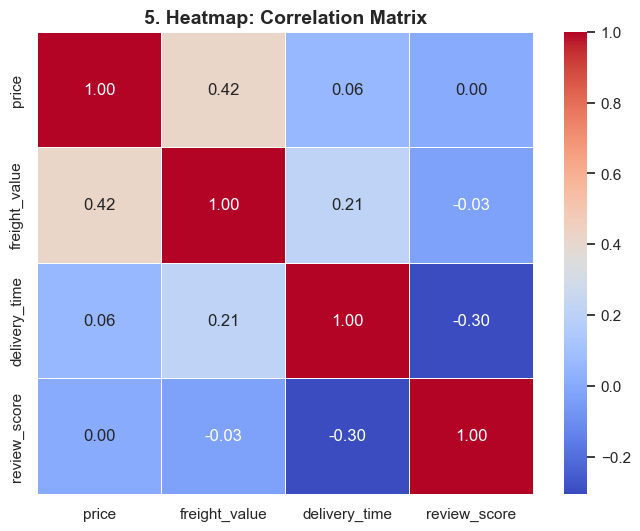


✅ Script completed! All charts have been saved to your Visualizations folder.


In [138]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define your folders
RAW_FOLDER = 'C://Users//Saptarshi Saha//Ecommerce_Intelligence_System'
RAW_Data = 'C://Users//Saptarshi Saha//Ecommerce_Intelligence_System'
# clean data to a new folder so you don't overwrite the raw data!
CLEAN_FOLDER = f'{RAW_FOLDER}//Cleaned_Data'
# Create a folder specifically for your saved charts!
VISUAL_FOLDER = f'{RAW_FOLDER}//Visualizations'

# Create the folders if they don't exist
os.makedirs(CLEAN_FOLDER, exist_ok=True)
os.makedirs(VISUAL_FOLDER, exist_ok=True)

print("--- 1. LOADING DATA ---")
orders = pd.read_csv(f"{RAW_Data}//orders.csv")
category_translation = pd.read_csv(f"{RAW_Data}//category_translation.csv")
customers = pd.read_csv(f"{RAW_Data}//customers.csv")
location = pd.read_csv(f"{RAW_Data}//location.csv")
order_item = pd.read_csv(f"{RAW_Data}//order_item.csv")
payments = pd.read_csv(f"{RAW_Data}//payments.csv")
reviews = pd.read_csv(f"{RAW_Data}//reviews.csv")
products = pd.read_csv(f"{RAW_Data}//products.csv")
sellers= pd.read_csv(f"{RAW_FOLDER}//sellers.csv")


print("--- 2. CLEANING & PREPROCESSING ---")

# --- Clean Orders ---
cols_to_drop = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
orders = orders.dropna(subset=cols_to_drop).copy()

cols_to_datachange = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in cols_to_datachange:
    orders[col] = pd.to_datetime(orders[col])

# --- Clean Order Items ---
order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'])

# --- Clean Products ---
prod_cols_to_drop = ['product_category_name', 'product_weight_g']
products = products.dropna(subset=prod_cols_to_drop).copy()

# --- Clean Reviews ---
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_score'] = pd.to_numeric(reviews['review_score'], errors='coerce')

# Check for and drop invalid review scores
valid_scores = reviews['review_score'].between(1, 5)
invalid_count = (~valid_scores).sum()
if invalid_count > 0:
    print(f"VALIDATION ALERT: Dropping {invalid_count} rows with impossible review scores.")
    reviews = reviews[valid_scores].copy() 

# --- Clean Location ---
location = location.drop_duplicates()


print("--- 3. DATA INTEGRATION (BUILDING MASTER DATASET) ---")

# Step 1: Merge Orders and Customers 
master_df = pd.merge(orders, customers, on='customer_id', how='inner')

# Step 2: Add Order Items 
master_df = pd.merge(master_df, order_item, on='order_id', how='inner')

# Step 3: Add Products details
master_df = pd.merge(master_df, products, on='product_id', how='inner')

# Step 4: Add Payments 
master_df = pd.merge(master_df, payments, on='order_id', how='left')

# Step 5: Add Reviews 
master_df = pd.merge(master_df, reviews, on='order_id', how='left')

# Step 6: Add Sellers details
master_df = pd.merge(master_df, sellers, on='seller_id', how='inner')

# Step 7: Add English Category Translations 
master_df = pd.merge(master_df, category_translation, on='product_category_name', how='left')

print("--- PROCESSING COMPLETE ---")
print(f"Final Master Dataset Shape (Rows, Columns): {master_df.shape}")


print("--- 4. Feature Engineering ---")

# 1. Total order value
master_df['total_item_cost'] = master_df['price'] + master_df['freight_value']
master_df['total_order_value'] = master_df.groupby('order_id')['total_item_cost'].transform('sum')

# 2. Delivery time
master_df['delivery_time'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.days

# 3. Number of items per order 
master_df['items_per_order'] = master_df.groupby('order_id')['order_item_id'].transform('max')

# 4. Customer purchase frequency 
master_df['customer_purchase_frequency'] = master_df.groupby('customer_id')['order_id'].transform('nunique')

# 5. Customer lifetime value
master_df['customer_lifetime_value'] = master_df.groupby('customer_id')['total_item_cost'].transform('sum')

# 6. Average order value per customer 
master_df['ave_order_value_customer'] = master_df['customer_lifetime_value'] / master_df['customer_purchase_frequency']


print("--- NEW VS REPEAT CUSTOMER ANALYSIS ---")

customer_orders = master_df.groupby('customer_unique_id')['order_id'].nunique()
new_customers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()

chart_data = pd.DataFrame({
    'Customer Type': ['One-Time Customers', 'Repeat Customers'],
    'Count': [new_customers, repeat_customers]
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=chart_data, x='Customer Type', y='Count', palette='pastel')
plt.title('New vs. Repeat Customers', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12)
plt.xlabel('') 
plt.savefig(f"{VISUAL_FOLDER}//new_vs_repeat_customers.png", bbox_inches='tight')
plt.show()


print("--- SIMPLE HIGH-VALUE VS LOW-VALUE ANALYSIS ---")

customer_spent = master_df.groupby('customer_unique_id')['total_item_cost'].sum().reset_index()
customer_spent.columns = ['customer_unique_id', 'total_spent']
average_spend = customer_spent['total_spent'].mean()

customer_spent['segment'] = 'Low-value'
customer_spent.loc[customer_spent['total_spent']>= average_spend, 'segment'] = 'High-value'
segment_counts= customer_spent['segment'].value_counts()

plt.figure(figsize=(6,4))
segment_counts.plot(kind='bar', color=['lightblue', 'orange'])
plt.title('HighValue vs LowValue Customers')
plt.ylabel('Number Of Customer')
plt.xlabel('Customer Type')
plt.savefig(f"{VISUAL_FOLDER}//high_vs_low_value.png", bbox_inches='tight')
plt.show()


print("--- GEOGRAPHIC DISTRIBUTION ---")

state_country = master_df.groupby('customer_state')['customer_unique_id'].nunique()
top_5_state = state_country.sort_values(ascending=False).head(5)

print("\n--- TOP 5 STATES BY CUSTOMER COUNT ---")
print(top_5_state)

plt.figure(figsize=(8,5))
top_5_state.plot(kind='bar', color='lightgreen')
plt.title('Top 5 States by Number of Unique Customers')
plt.ylabel('Number of Customer')
plt.xlabel('State')
plt.xticks(rotation=0)
plt.savefig(f"{VISUAL_FOLDER}//top_5_states.png", bbox_inches='tight')
plt.show()


print("--- TOP-SELLING PRODUCT CATEGORIES (BY REVENUE) ---")

category_revenue = master_df.groupby('product_category_name_english')['total_item_cost'].sum()
top_10_category = category_revenue.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_10_category.plot(kind='bar', color = 'blue')
plt.title('Top 10 Product Categories by Total Revenue', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Product Category')
plt.xticks(rotation=45, ha='right')
plt.savefig(f"{VISUAL_FOLDER}//top_10_categories_revenue.png", bbox_inches='tight')
plt.show()


print("--- SIMPLE REVENUE CONTRIBUTION (TOP 10) ---")

category_revenue = master_df.groupby('product_category_name_english')['total_item_cost'].sum().reset_index()
top_10_categories = category_revenue.sort_values(by='total_item_cost', ascending=False).head(10)

plt.figure(figsize=(8, 8))
plt.pie(
    top_10_categories['total_item_cost'], 
    labels=top_10_categories['product_category_name_english'], 
    autopct='%1.1f%%', 
    startangle=140
)
plt.title('Revenue Contribution (Top 10 Categories)', fontsize=16, fontweight='bold')
plt.savefig(f"{VISUAL_FOLDER}//top_10_categories_pie.png", bbox_inches='tight')
plt.show()


print("--- PRODUCT DEMAND DISTRIBUTION (TOP 10) ---")

demand_distribution = master_df['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(10, 6))
demand_distribution.plot(kind='bar', color='mediumpurple')
plt.title('Product Demand Distribution (Top 10 Categories)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Items Sold', fontsize=12)
plt.xlabel('Product Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.savefig(f"{VISUAL_FOLDER}//product_demand_distribution.png", bbox_inches='tight')
plt.show()


print("--- MONTHLY REVENUE TRENDS ---")

master_df['order_month'] = master_df['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_revenue = master_df.groupby('order_month')['total_item_cost'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', color='teal', marker='o' ,linewidth=2)
plt.title('Monthly Revenue Trends', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.savefig(f"{VISUAL_FOLDER}//monthly_revenue_trends.png", bbox_inches='tight')
plt.show()


print("--- MONTHLY ORDER VOLUME TRENDS ---")

master_df['order_month'] = master_df['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_volume = master_df.groupby('order_month')['order_id'].nunique()

plt.figure(figsize=(12,5))
monthly_volume.plot(kind='line', color= 'darkorange', marker='s',linewidth=2)
plt.title('Monthly Order Volume Trends', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders Placed', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.savefig(f"{VISUAL_FOLDER}//monthly_volume_trends.png", bbox_inches='tight')
plt.show()


print("--- PEAK SALES PERIODS (HOUR OF THE DAY) ---")

master_df['order_hour'] = master_df['order_purchase_timestamp'].dt.hour
peak_hours = master_df.groupby('order_hour')['order_id'].nunique()

plt.figure(figsize=(10, 5))
peak_hours.plot(kind='bar', color='crimson')
plt.title('Peak Sales Periods by Hour of the Day', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=12)
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)
plt.xticks(rotation=0)
plt.savefig(f"{VISUAL_FOLDER}//peak_sales_hours.png", bbox_inches='tight')
plt.show()


print("--- TOP-PERFORMING SELLERS (BY REVENUE) ---")

seller_revenue = master_df.groupby('seller_id')['total_item_cost'].sum().reset_index()
top_10_sellers = seller_revenue.sort_values(by='total_item_cost', ascending=False).head(10)

plt.figure(figsize=(10, 6))
short_seller_ids = top_10_sellers['seller_id'].astype(str).str[:6]
plt.bar(short_seller_ids, top_10_sellers['total_item_cost'], color='gold')
plt.title('Top 10 Performing Sellers by Total Revenue', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xlabel('Seller ID (First 6 characters)', fontsize=12)
plt.xticks(rotation=45)
plt.savefig(f"{VISUAL_FOLDER}//top_10_sellers_revenue.png", bbox_inches='tight')
plt.show()


print("--- SIMPLE SELLER CONTRIBUTION (TOP 5 ONLY) ---")

seller_revenue = master_df.groupby('seller_id')['total_item_cost'].sum().reset_index()
top_5_sellers = seller_revenue.sort_values(by='total_item_cost', ascending=False).head(5).copy()
top_5_sellers['seller_id'] = top_5_sellers['seller_id'].astype(str).str[:6]

plt.figure(figsize=(8, 8))
plt.pie(
    top_5_sellers['total_item_cost'], 
    labels=top_5_sellers['seller_id'], 
    autopct='%1.1f%%', 
    startangle=140
)
plt.title('Revenue Contribution (Top 5 Sellers Only)', fontsize=16, fontweight='bold')
plt.savefig(f"{VISUAL_FOLDER}//top_5_sellers_pie.png", bbox_inches='tight')
plt.show()


print("--- SELLER GEOGRAPHIC DISTRIBUTION (TOP 10 STATES) ---")

seller_distribution = sellers['seller_state'].value_counts().head(10)

plt.figure(figsize=(10, 5))
seller_distribution.plot(kind='bar', color='cornflowerblue')
plt.title('Top 10 States by Number of Sellers', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sellers', fontsize=12)
plt.xlabel('State Code', fontsize=12)
plt.xticks(rotation=0)
plt.savefig(f"{VISUAL_FOLDER}//seller_distribution.png", bbox_inches='tight')
plt.show()


print("--- REVIEW SCORE DISTRIBUTION ---")

score_distribution = master_df['review_score'].value_counts().sort_index()

print("\n--- COUNT OF REVIEW SCORES ---")
print(score_distribution)

plt.figure(figsize=(8, 5))
score_distribution.plot(kind='bar', color='royalblue')
plt.title('Distribution of Review Scores (1 to 5 Stars)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Reviews', fontsize=12)
plt.xlabel('Review Score (Stars)', fontsize=12)
plt.xticks(rotation=0)
plt.savefig(f"{VISUAL_FOLDER}//review_score_distribution.png", bbox_inches='tight')
plt.show()


print("--- RELATIONSHIP: DELIVERY TIME VS RATINGS ---")

delivery_by_score = master_df.groupby('review_score')['delivery_time'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(delivery_by_score['review_score'], delivery_by_score['delivery_time'], color='salmon')
plt.title('Average Delivery Time vs. Review Score', fontsize=14, fontweight='bold')
plt.ylabel('Average Delivery Time (Days)', fontsize=12)
plt.xlabel('Review Score (Stars)', fontsize=12)
plt.savefig(f"{VISUAL_FOLDER}//delivery_vs_ratings.png", bbox_inches='tight')
plt.show()


print("--- DISSATISFACTION PATTERNS (1-STAR REVIEWS) ---")

angry_customers = master_df[master_df['review_score'] == 1]
bad_categories = angry_customers['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(10, 6))
bad_categories.plot(kind='bar', color='firebrick')
plt.title('Dissatisfaction Patterns: Most 1-Star Reviews by Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of 1-Star Reviews', fontsize=12)
plt.xlabel('Product Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.savefig(f"{VISUAL_FOLDER}//dissatisfaction_patterns.png", bbox_inches='tight')
plt.show()


print("--- STEP 6: DATA VISUALIZATION GENERATOR ---")

sns.set_theme(style="whitegrid")

# 1. TIME SERIES PLOT (Sales Trends)
plt.figure(figsize=(12, 5))
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_sales = master_df.groupby('order_month')['total_item_cost'].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, color='teal', marker='o', linewidth=2)
plt.title('1. Time Series: Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.savefig(f"{VISUAL_FOLDER}//step6_1_time_series.png", bbox_inches='tight')
plt.show()


# 2. BAR CHART (Category Performance)
plt.figure(figsize=(10, 6))
top_categories = master_df['product_category_name_english'].value_counts().head(10)

sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('2. Bar Chart: Top 10 Product Categories by Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Items Sold')
plt.ylabel('Category')
plt.savefig(f"{VISUAL_FOLDER}//step6_2_bar_chart.png", bbox_inches='tight')
plt.show()


# 3. HISTOGRAM (Distribution Analysis)
plt.figure(figsize=(10, 5))
normal_prices = master_df[master_df['price'] < 500]

sns.histplot(data=normal_prices, x='price', bins=40, color='coral', kde=True)
plt.title('3. Histogram: Distribution of Product Prices (Under $500)', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Frequency (Number of Items)')
plt.savefig(f"{VISUAL_FOLDER}//step6_3_histogram.png", bbox_inches='tight')
plt.show()


# 4. BOX PLOT (Outlier Detection)
plt.figure(figsize=(10, 3))
sns.boxplot(data=master_df, x='freight_value', color='mediumpurple')
plt.title('4. Box Plot: Freight Value Outlier Detection', fontsize=14, fontweight='bold')
plt.xlabel('Freight Value / Shipping Cost ($)')
plt.savefig(f"{VISUAL_FOLDER}//step6_4_boxplot.png", bbox_inches='tight')
plt.show()


# 5. HEATMAP (Correlation Analysis)
plt.figure(figsize=(8, 6))
cols_to_compare = ['price', 'freight_value', 'delivery_time', 'review_score']
correlation_matrix = master_df[cols_to_compare].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('5. Heatmap: Correlation Matrix', fontsize=14, fontweight='bold')
plt.savefig(f"{VISUAL_FOLDER}//step6_5_heatmap.png", bbox_inches='tight')
plt.show()

print("\n Script completed! All charts have been saved to your Visualizations folder.")